# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
# importar librerías
import pandas as pd
import numpy as np

In [2]:
orders = pd.read_csv('/datasets/instacart_orders.csv',sep=";")# leer conjuntos de datos en los DataFrames

In [3]:
# mostrar información del DataFrame
orders.info()
print(orders.head(3))
print()
print(orders.isna().sum())
print()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  

order_id             

In [4]:
# mostrar información del DataFrame
products = pd.read_csv('/datasets/products.csv',sep=";")
products.info()
print(products.head()) 
print()
print(products.isna().sum())
print()
print(products.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  



In [5]:
# mostrar información del DataFrame
order_products = pd.read_csv('/datasets/order_products.csv',sep=";")
order_products.info()
print()
order_products.head()
print()
print(order_products.isna().sum())
print()
print(order_products.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

0


In [6]:
# mostrar información del DataFrame
aisles = pd.read_csv('/datasets/aisles.csv',sep=";")
aisles.info()
print()
aisles.head()
print()
print(aisles.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


aisle_id    0
aisle       0
dtype: int64


In [7]:
# mostrar información del DataFrame
departments = pd.read_csv('/datasets/departments.csv',sep=";")
departments.info()
print()
departments.head()
print()
print(departments.isna().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


department_id    0
department       0
dtype: int64


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

orders 

-En la columna days_since_prior_order hay 28819 NaN. 

-La columna days_since_prior_order está como float por los NaN.

products

-En la columna product_name hay 1258 NaN.

order_products

-En la columna add_to_cart_order hay 836 NaN.

aisles

-No tiene complicaciones. 

departments

-No tiene complicaciones. 




# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
print(orders.duplicated().sum()) #todos los duplicados
print()
print(orders[orders.duplicated()]) #ver las 15 filas 
print()
print(orders[orders.duplicated()].drop_duplicates()) # duplicados exactos que se estén repitiendo
print()
print(orders[orders.duplicated(subset=['order_id'])].head(15)) #ver que Id's se repiten
print()
duplicates = orders[orders.duplicated(keep=False)] #guardamos los duplicados en una variable
print()
print()
print()
duplicates.value_counts().head()



15

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48        

order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order
391768    57671    19            3          2                  10.0                      2
408114    68324    4             3          2                  18.0                      2
467134    63189    21            3          2                  2.0                       2
794638    50898    24            3          2                  2.0                       2
1021560   53767    3             3          2                  9.0                       2
dtype: int64

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

En los 15 duplicados son 5 Id´s los que generaón los duplicados.

En todos los duplicados sale registro de Miércoles (order_row).

En todos los duplicados sale registro de a las 2:00 am (order_hour_of_day).

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
# Filtrar pedidos hechos el miércoles a las 2:00 a.m.

wed_2am_orders = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)] #le agregamos una varable e imprimimos las filas con shape

print("Número de pedidos el miércoles a las 2:00 a.m.:", wed_2am_orders.shape[0])
print()
print()
wed_2am_orders.head()


Número de pedidos el miércoles a las 2:00 a.m.: 121




,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0


¿Qué sugiere este resultado?

Hubo algún bug con la aplicación durante las 2:00 am, que afectaron 5 usuarios. 

Hay 121 pedidos a las 2:00 am, quizá y son de otro país con otro horario o gente que compra en la madrugada.


In [10]:
# Elimina los pedidos duplicados
orders.drop_duplicates(inplace=True)

print("Número de filas después de eliminar duplicados:", orders.shape[0])



Número de filas después de eliminar duplicados: 478952


In [11]:
# Vuelve a verificar si hay filas duplicadas
print("Número de duplicados después de limpiar:", orders.duplicated().sum())

Número de duplicados después de limpiar: 0


In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
duplicados_order_id = orders['order_id'].duplicated().sum()

print("Número de order_id duplicados:", duplicados_order_id)


Número de order_id duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos

Al analizar la tabla orders, detecté 15 filas duplicadas, concentradas en pocos order_id. Los pedidos fueron en horarios inusuales (miércoles a las 2:00 a.m.), lo que confirmaba que no eran duplicados random. Algo se bugeo a esa hora. 

Eliminé los registros duplicados y verifiqué que ya no quedaran order_id repetidos. Ahora el DF solo tiene un pedido único por cliente y Id.

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
# Revisa si hay pedidos duplicados

print(f'De {len(products)} filas hay {products.duplicated().sum()} duplicados') #duplicados 


De 49694 filas hay 0 duplicados


In [14]:
# Revisa únicamente si hay ID de productos duplicados
product_id_dup= products['product_id'].duplicated().sum()
print("product_id duplicados:",product_id_dup)

product_id duplicados: 0


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)

products['product_name_upper'] = products['product_name'].str.upper()

#Contar cuántos nombres únicos vs totales
total_nombres = products['product_name_upper'].shape[0]
nombres_unicos = products['product_name_upper'].nunique()

print("Total de nombres de productos:", total_nombres)
print("Nombres de productos únicos:", nombres_unicos)
print("Duplicados de nombre:", total_nombres - nombres_unicos)

#Ver ejemplos de productos duplicados
duplicados_nombre = products[products['product_name_upper'].duplicated(keep=False)]
print()
print("Ejemplos de nombres duplicados:")
print()
print(duplicados_nombre.sort_values('product_name_upper').head(10))


Total de nombres de productos: 49694
Nombres de productos únicos: 48332
Duplicados de nombre: 1362

Ejemplos de nombres duplicados:

       product_id                               product_name  aisle_id  \
23339       23340  18-in-1 Hemp Peppermint Pure-Castile Soap        25   
31844       31845  18-In-1 Hemp Peppermint Pure-Castile Soap        25   
19941       19942            Aged Balsamic Vinegar Of Modena        19   
13152       13153            Aged Balsamic Vinegar of Modena        19   
24830       24831         Albacore Solid White Tuna in Water        95   
22582       22583         Albacore Solid White Tuna In Water        95   
9037         9038                     American Cheese slices        21   
515           516                     American Cheese Slices        21   
49530       49531               Anchovy Fillets In Olive Oil        95   
12325       12326               Anchovy Fillets in Olive Oil        95   

       department_id                         product

In [16]:
# Revisa si hay nombres duplicados de productos no faltantes


products_no_null = products[products['product_name'].notna()].copy()


products_no_null['product_name_upper'] = products_no_null['product_name'].str.upper()


total_nombres = products_no_null['product_name_upper'].shape[0]
nombres_unicos = products_no_null['product_name_upper'].nunique()

print("Total de nombres de productos (no nulos):", total_nombres)
print("Nombres de productos únicos:", nombres_unicos)
print("Duplicados de nombre:", total_nombres - nombres_unicos)


duplicados_nombre = products_no_null[products_no_null['product_name_upper'].duplicated(keep=False)]
print("Ejemplos de productos con nombre duplicado:")
print()
print(duplicados_nombre.sort_values('product_name_upper').head(10))


Total de nombres de productos (no nulos): 48436
Nombres de productos únicos: 48332
Duplicados de nombre: 104
Ejemplos de productos con nombre duplicado:

       product_id                               product_name  aisle_id  \
23339       23340  18-in-1 Hemp Peppermint Pure-Castile Soap        25   
31844       31845  18-In-1 Hemp Peppermint Pure-Castile Soap        25   
19941       19942            Aged Balsamic Vinegar Of Modena        19   
13152       13153            Aged Balsamic Vinegar of Modena        19   
24830       24831         Albacore Solid White Tuna in Water        95   
22582       22583         Albacore Solid White Tuna In Water        95   
9037         9038                     American Cheese slices        21   
515           516                     American Cheese Slices        21   
49530       49531               Anchovy Fillets In Olive Oil        95   
12325       12326               Anchovy Fillets in Olive Oil        95   

       department_id           

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se detectaron 104 nombres de producto duplicados (principalmente por diferencias en mayúsculas y minúsculas), pero cada registro mantiene un product_id único, por lo que no se eliminarlos sería un error. Se tendría que revisar porque marca un Id único. 

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
print("Filas duplicadas completas:", departments.duplicated().sum())


Filas duplicadas completas: 0


In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
dept_id_dup = departments['department_id'].duplicated().sum()
print("department_id duplicados:", dept_id_dup)
print("Total de filas:", departments.shape[0])
print("department_id únicos:", departments['department_id'].nunique())

department_id duplicados: 0
Total de filas: 21
department_id únicos: 21


Describe brevemente tus hallazgos y lo que hiciste con ellos.

En la tabla departments no se encontraron filas ni department_id duplicados. Se confirmaron 21 filas únicas y cada departamento tiene un identificador único, por lo que no fue necesario realizar cambios.


### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
print("Filas duplicadas completas:", aisles.duplicated().sum())

Filas duplicadas completas: 0


In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
dup_aisle_id = aisles['aisle_id'].duplicated().sum()
print("aisle_id duplicados:", dup_aisle_id)
print("Total de filas:", aisles.shape[0])
print("aisle_id únicos:", aisles['aisle_id'].nunique())

aisle_id duplicados: 0
Total de filas: 134
aisle_id únicos: 134


Describe brevemente tus hallazgos y lo que hiciste con ellos.

En la tabla aisles no se encontraron filas duplicadas ni aisle_id repetidos. Cada pasillo cuenta con un identificador único, por lo que no fue necesario hacer correcciones.

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
print("Filas duplicadas completas:", order_products.duplicated().sum())

Filas duplicadas completas: 0


In [22]:

dup_pairs = order_products.duplicated(subset=['order_id', 'product_id']).sum()
print("Duplicados de pares (order_id, product_id):", dup_pairs)

if dup_pairs > 0:
    dup_examples = order_products[
        order_products.duplicated(subset=['order_id', 'product_id'], keep=False)
    ]
    print("Ejemplos de duplicados engañosos:")
    print(dup_examples.head(10))


    top_pairs = (
        dup_examples
        .value_counts(subset=['order_id', 'product_id'])
        .head(10)
    )
    print("Top pares duplicados:")
    print(top_pairs)
else:
    print("No hay pares (order_id, product_id) repetidos; no se muestran ejemplos ni top.")


Duplicados de pares (order_id, product_id): 0
No hay pares (order_id, product_id) repetidos; no se muestran ejemplos ni top.


Describe brevemente tus hallazgos y lo que hiciste con ellos.

En la tabla order_products no se encontraron duplicados engañosos de pares (order_id, product_id). Cada producto aparece una sola vez por pedido, por lo que no fue necesario realizar ajustes.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
missing_products = products[products['product_name'].isna()]
print("Número de productos con nombre ausente:", missing_products.shape[0])
missing_products.head()

Número de productos con nombre ausente: 1258


,product_id,product_name,aisle_id,department_id,product_name_upper
37,38,NaN,100,21,NaN
71,72,NaN,100,21,NaN
109,110,NaN,100,21,NaN
296,297,NaN,100,21,NaN
416,417,NaN,100,21,NaN


Describe brevemente cuáles son tus hallazgos.

Al parecer todos tienen el mismo aisle_id y department_id.


In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print(missing_products['aisle_id'].unique())


[100]


Describe brevemente cuáles son tus hallazgos.

Comprobamos que todos los productos con nombre ausente pertenecen exclusivamente al pasillo con ID 100.


In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print(missing_products['department_id'].unique())

[21]


Describe brevemente cuáles son tus hallazgos.

Comprobamos que todos los productos con nombre ausente pertenecen exclusivamente al departamento con ID 21.

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.

print("Pasillo con ID 100:")
print(aisles[aisles['aisle_id'] == 100])
print()
print()
print("Departamento con ID 21:")
print(departments[departments['department_id'] == 21])


Pasillo con ID 100:
    aisle_id    aisle
99       100  missing


Departamento con ID 21:
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

Los productos con product_name ausente están asociados al pasillo con ID 100 y al departamento con ID 21, ambos nombrados como "missing". Esto confirma que los valores faltantes fueron agrupados en categorías especiales, por lo que se completaron los nombres vacíos con "Unknown" para mantener consistencia en el dataset.

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'

products['product_name'] = products['product_name'].fillna('Unknown')

print("Valores nulos en product_name después de la corrección:", products['product_name'].isna().sum())



Valores nulos en product_name después de la corrección: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se reemplazaron los valores nulos en product_name por "Unknown". Después de corregir, ya no quedaron nombres de producto ausentes en la tabla products.

### `orders` data frame

In [28]:
# Encuentra los valores ausentes
missing_orders = orders[orders['days_since_prior_order'].isna()]
print(missing_orders.head(3))


     order_id  user_id  order_number  order_dow  order_hour_of_day  \
28     133707   182261             1          3                 10   
96     787445    25685             1          6                 18   
100    294410   111449             1          0                 19   

     days_since_prior_order  
28                      NaN  
96                      NaN  
100                     NaN  


In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print("Número de valores ausentes en days_since_prior_order:", missing_orders.shape[0])

print(missing_orders['order_number'].unique())

Número de valores ausentes en days_since_prior_order: 28817
[1]


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Como el resultado fue [1], confirma que todos los NaN están solo en el primer pedido de cada cliente.

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes
missing_order_products = order_products[order_products['add_to_cart_order'].isna()]
print("Número de valores ausentes en add_to_cart_order:", missing_order_products.shape[0])
missing_order_products.head()

Número de valores ausentes en add_to_cart_order: 836


,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print("Valor mínimo en add_to_cart_order:", order_products['add_to_cart_order'].min())
print("Valor máximo en add_to_cart_order:", order_products['add_to_cart_order'].max())


Valor mínimo en add_to_cart_order: 1.0
Valor máximo en add_to_cart_order: 64.0


Describe brevemente cuáles son tus hallazgos.

Los valores van desde 1 producto agregado al carrito hasta 64 productos agregados al carrito.

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

missing_cart_orders = order_products[order_products['add_to_cart_order'].isna()]


missing_cart_ids = missing_cart_orders['order_id'].unique()

print("Número de pedidos con add_to_cart_order ausente:", len(missing_cart_ids))
print("Ejemplos de IDs de pedidos con valores ausentes:", missing_cart_ids[:10])


Número de pedidos con add_to_cart_order ausente: 70
Ejemplos de IDs de pedidos con valores ausentes: [2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093]


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.


missing_cart_orders = order_products[order_products['add_to_cart_order'].isna()]


missing_cart_counts = missing_cart_orders.groupby('order_id')['product_id'].count()


print("Número de pedidos con valores ausentes:", len(missing_cart_counts))
print("Número mínimo de productos en esos pedidos:", missing_cart_counts.min())
print("Número máximo de productos en esos pedidos:", missing_cart_counts.max())

Número de pedidos con valores ausentes: 70
Número mínimo de productos en esos pedidos: 1
Número máximo de productos en esos pedidos: 63


Describe brevemente cuáles son tus hallazgos.

Los valores ausentes en add_to_cart_order afectan a 70 pedidos con entre 1 y 63 productos. 

Esto confirma que los NaN no se deben únicamente a pedidos con más de 64 productos, por lo que representan inconsistencias en los datos.

In [34]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.


order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)


order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)


print("Valores nulos en add_to_cart_order después de corrección:", 
      order_products['add_to_cart_order'].isna().sum())
print("Tipo de dato de la columna:", order_products['add_to_cart_order'].dtype)




Valores nulos en add_to_cart_order después de corrección: 0
Tipo de dato de la columna: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Después de la corrección, no quedaron nulos y la columna fue convertida correctamente al tipo entero int64.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

En la tabla products, se detectaron valores nulos en la columna product_name. Confirmamos que todos estaban asociados al pasillo con ID 100 y al departamento con ID 21, ambos nombrados como "missing". Los valores ausentes fueron reemplazados por "Unknown".

En la tabla orders, los valores nulos en days_since_prior_order (28,817 casos) se encontraron únicamente en el primer pedido de cada cliente, lo cual es lógico porque no existe un pedido anterior. Por lo tanto, no fue necesario reemplazarlos ni eliminarlos.

En la tabla order_products, se detectaron valores nulos en add_to_cart_order. Tras analizarlos, comprobamos que no estaban relacionados con pedidos de gran tamaño, ya que aparecían incluso en pedidos pequeños (1 a 63 productos). Estos valores fueron reemplazados por 999 para señalarlos como casos especiales, y la columna fue convertida al tipo entero (int64).


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [35]:
print("Valores únicos de order_hour_of_day:", orders['order_hour_of_day'].unique().min(), "a", orders['order_hour_of_day'].unique().max())

Valores únicos de order_hour_of_day: 0 a 23


In [36]:
print("Valores únicos de order_dow:", orders['order_dow'].unique().min(), "a", orders['order_dow'].unique().max())

Valores únicos de order_dow: 0 a 6


Escribe aquí tus conclusiones

Los valores en order_hour_of_day oscilan entre 0 y 23 y los de order_dow entre 0 y 6, sin registros fuera de rango.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

Máximo de pedidos por hora: 40578
Mínimo de pedidos por hora: 765


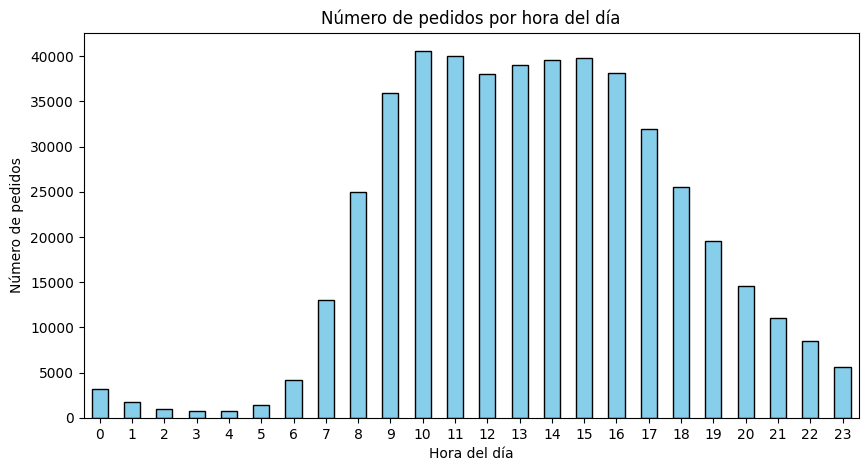

In [37]:
import matplotlib.pyplot as plt


orders_per_hour = orders['order_hour_of_day'].value_counts().sort_index()


print("Máximo de pedidos por hora:",orders_per_hour.max())
print("Mínimo de pedidos por hora:",orders_per_hour.min())


orders_per_hour.plot(kind='bar',
                     color='skyblue',
                     edgecolor='black',
                     rot=0,
                     figsize=[10,5]
                    )

plt.title("Número de pedidos por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Número de pedidos")
plt.show()


Escribe aquí tus conclusiones

Los pedidos se disparan desde las 7:00 am llegando su máximo a las 10:am para luego empezar a decender a las 5:00 pm. 

### [A3] ¿Qué día de la semana compran víveres las personas?

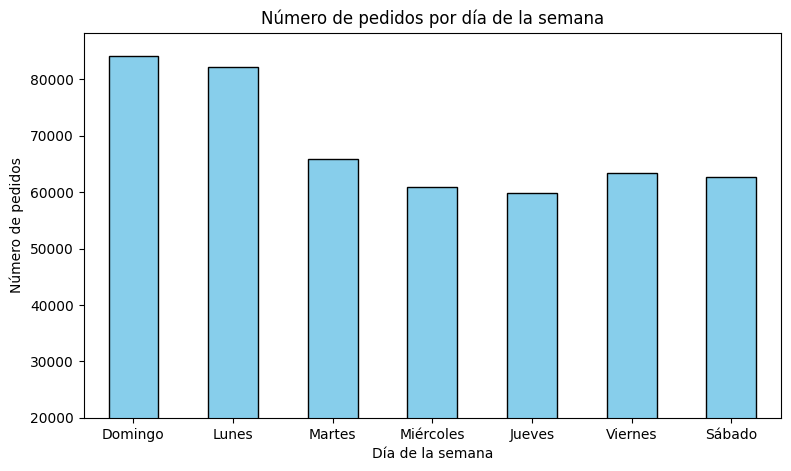

In [38]:

orders_per_dow = orders['order_dow'].value_counts().sort_index()

orders_per_dow = orders_per_dow.rename(index={0:'Domingo',1:'Lunes',2:'Martes',3:'Miércoles',
                                              4:'Jueves',5:'Viernes',6:'Sábado'})

orders_per_dow.plot(kind='bar',
                    figsize=(9,5), 
                    color='skyblue', 
                    edgecolor='black',
                    ylim=[20000,None]
)
plt.title("Número de pedidos por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=0)
plt.show()


Escribe aquí tus conclusiones

Los días con mayor volumen de compras son domingo y lunes, superando los 80,000 pedidos, mientras que el resto de la semana presenta un nivel más estable, alrededor de los 60,000–65,000 pedidos diarios


### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Mínimo: 0.0
Máximo: 30.0


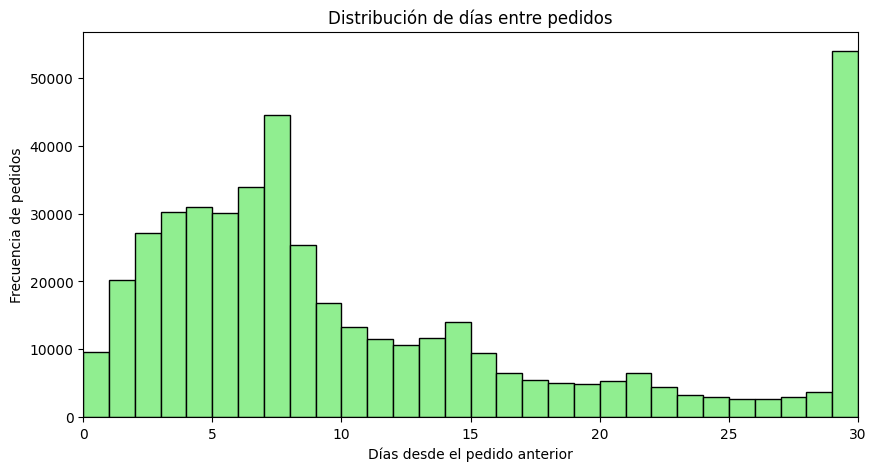

In [39]:
print("Mínimo:", orders['days_since_prior_order'].min())
print("Máximo:", orders['days_since_prior_order'].max())

orders['days_since_prior_order'].plot(
    kind='hist',
    bins=30,
    figsize=(10,5),
    color='lightgreen',
    edgecolor='black',
)


plt.xlim(0, 30)
plt.ylim(0, None)
plt.title("Distribución de días entre pedidos")
plt.xlabel("Días desde el pedido anterior")
plt.ylabel("Frecuencia de pedidos")
plt.show()




Escribe aquí tus conclusiones

La mayoría de los clientes vuelve a hacer un pedido dentro de 7 días (un ciclo semanal).

Se observa un pico muy alto en 30 días, lo que puede indicar clientes que hacen compras mensuales.



# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt


In [41]:
wednesday_orders = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
saturday_orders  = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

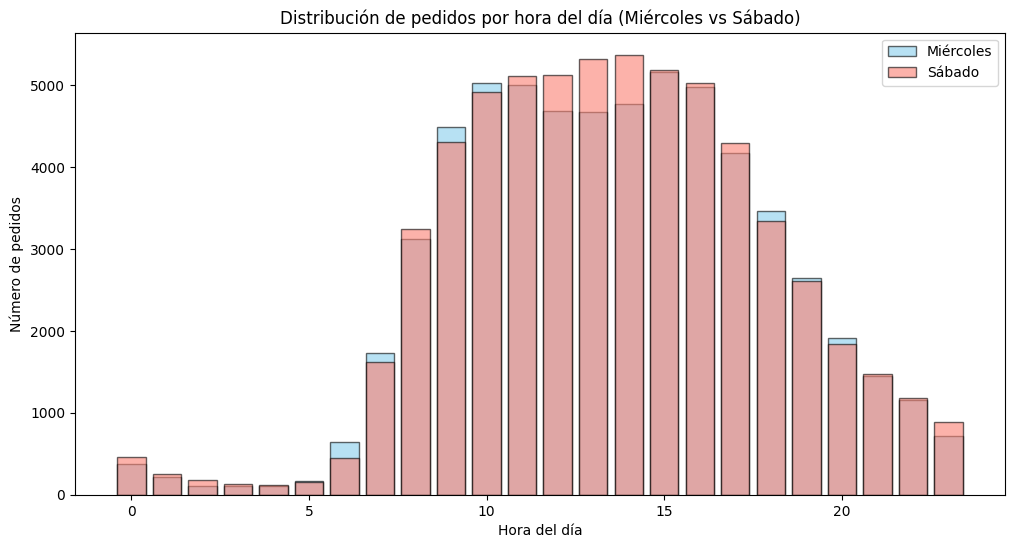

In [42]:
plt.figure(figsize=(12,6))

plt.bar(wednesday_orders.index,
        wednesday_orders.values, 
        alpha=0.6,
        label='Miércoles',
        color='skyblue',
        edgecolor='black'
)



plt.bar(saturday_orders.index,
        saturday_orders.values, 
        alpha=0.6,
        label='Sábado',
        color='salmon',
        edgecolor='black'
)

plt.title("Distribución de pedidos por hora del día (Miércoles vs Sábado)")
plt.xlabel("Hora del día")
plt.ylabel("Número de pedidos")
plt.legend()
plt.show()

Escribe aquí tus conclusiones

Tienen un patrón con muy poca diferencia.

El sábado es un día más activo en términos de volumen de compras, probablemente porque más usuarios aprovechan su tiempo libre para hacer pedidos, y los miércoles se concentran en horarios laborales y de comida.


### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [43]:
orders_per_user = orders.groupby('user_id')['order_id'].count()
print(orders_per_user.describe())
print()
print()
print(orders_per_user.value_counts().head(10))

count    157437.000000
mean          3.042182
std           2.746842
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          28.000000
Name: order_id, dtype: float64


1     55357
2     36508
3     21547
4     13498
5      8777
6      6012
7      4240
8      3019
9      2152
10     1645
Name: order_id, dtype: int64


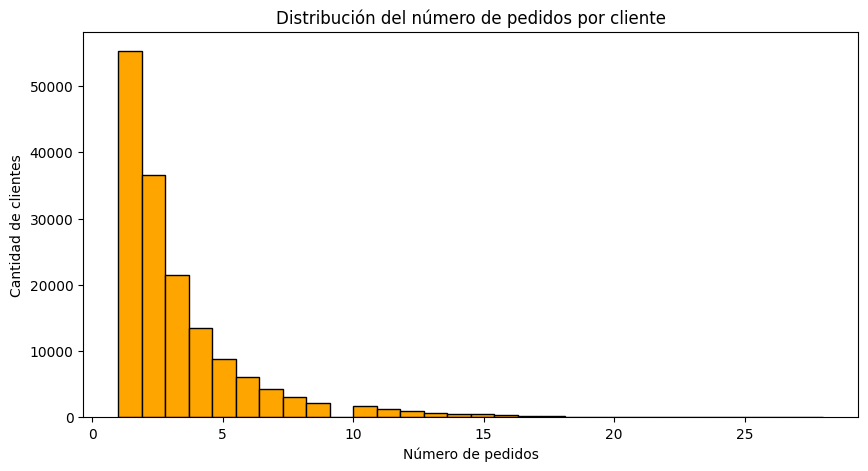

In [44]:
import matplotlib.pyplot as plt

orders_per_user.plot(
    kind='hist',
    bins=30,
    figsize=(10,5),
    color='orange',
    edgecolor='black'
)

plt.title("Distribución del número de pedidos por cliente")
plt.xlabel("Número de pedidos")
plt.ylabel("Cantidad de clientes")
plt.show()


Escribe aquí tus conclusiones

La mayoría de los clientes tienen entre 1 y 2 pedidos, siendo 1 pedido el caso más común (más de 55 mil clientes).

La grafica disminuye rápidamente, lo que indica que los clientes son nuevos. 



### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [45]:
top_products = order_products['product_id'].value_counts().head(20)
print(top_products)

24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
27966    19197
22935    15898
24964    15292
45007    14584
39275    13879
49683    13675
28204    12544
5876     12232
8277     11993
40706    11781
Name: product_id, dtype: int64


In [46]:
top_products = top_products.reset_index()
top_products.columns = ['product_id', 'count']

In [47]:
top_products = top_products.merge(products[['product_id', 'product_name']], 
                                  on='product_id',
                                  how='left'
)

print(top_products)

    product_id  count              product_name
0        24852  66050                    Banana
1        13176  53297    Bag of Organic Bananas
2        21137  37039      Organic Strawberries
3        21903  33971      Organic Baby Spinach
4        47209  29773      Organic Hass Avocado
5        47766  24689           Organic Avocado
6        47626  21495               Large Lemon
7        16797  20018              Strawberries
8        26209  19690                     Limes
9        27845  19600        Organic Whole Milk
10       27966  19197       Organic Raspberries
11       22935  15898      Organic Yellow Onion
12       24964  15292            Organic Garlic
13       45007  14584          Organic Zucchini
14       39275  13879       Organic Blueberries
15       49683  13675            Cucumber Kirby
16       28204  12544        Organic Fuji Apple
17        5876  12232             Organic Lemon
18        8277  11993  Apple Honeycrisp Organic
19       40706  11781    Organic Grape T

Escribe aquí tus conclusiones

Banana es el líder absoluto (66k órdenes).

Predominan frutas y verduras frescas.

Alta presencia de “orgánicos”.


# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


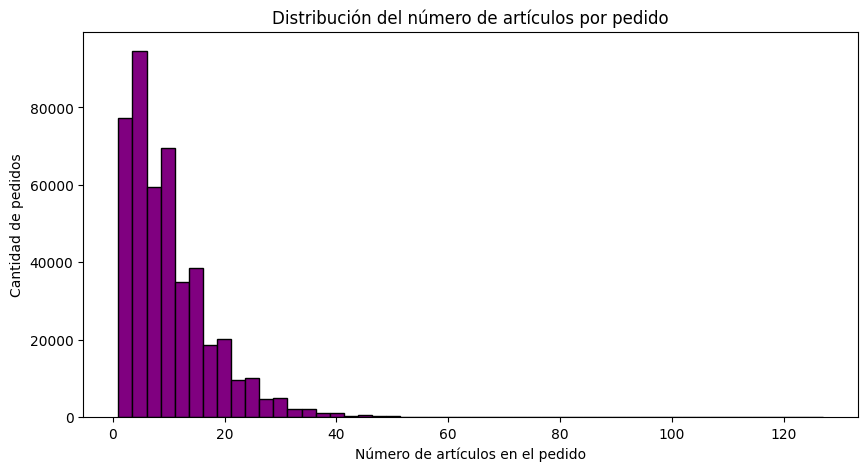

In [48]:
import matplotlib.pyplot as plt


items_per_order = order_products.groupby('order_id')['product_id'].count()


print(items_per_order.describe())


items_per_order.plot(
    kind='hist',
    bins=50,
    figsize=(10,5),
    color='purple',
    edgecolor='black'
)

plt.title("Distribución del número de artículos por pedido")
plt.xlabel("Número de artículos en el pedido")
plt.ylabel("Cantidad de pedidos")
plt.show()

Escribe aquí tus conclusiones

La mayoría de los pedidos contienen entre 5 y 14 artículos, con una mediana de 8. Aunque existen pedidos muy grandes (hasta 127 artículos),pero son poco frecuentes (valores atípicos). Esto indica que el comportamiento típico de los clientes es realizar compras de tamaño medio–pequeño.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [49]:
reordered = order_products[order_products['reordered'] == 1]

In [50]:
reorders_per_product = (
    reordered
    .groupby('product_id', as_index=False)
    .size()
    .rename(columns={'size': 'reorder_count'})
)

In [51]:
top20_reorders = (
    reorders_per_product
    .sort_values('reorder_count', ascending=False)
    .head(20)
)

In [52]:
top20_reorders = (
    top20_reorders
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
    [['product_id', 'product_name', 'reorder_count']]
)

print(top20_reorders)

    product_id              product_name  reorder_count
0        24852                    Banana          55763
1        13176    Bag of Organic Bananas          44450
2        21137      Organic Strawberries          28639
3        21903      Organic Baby Spinach          26233
4        47209      Organic Hass Avocado          23629
5        47766           Organic Avocado          18743
6        27845        Organic Whole Milk          16251
7        47626               Large Lemon          15044
8        27966       Organic Raspberries          14748
9        16797              Strawberries          13945
10       26209                     Limes          13327
11       22935      Organic Yellow Onion          11145
12       24964            Organic Garlic          10411
13       45007          Organic Zucchini          10076
14       49683            Cucumber Kirby           9538
15       28204        Organic Fuji Apple           8989
16        8277  Apple Honeycrisp Organic        

Escribe aquí tus conclusiones

Al igual que en los productos más populares (B3), los artículos más reordenados son principalmente frutas y vegetales frescos, en especial productos orgánicos como bananas, fresas, espinaca, aguacates y manzanas. La diferencia es que en este caso se confirma que no solo son los más pedidos inicialmente, sino también los que los clientes mantienen de forma constante en sus compras recurrentes, lo cual refleja un alto nivel de fidelidad y hábito de consumo en estos productos.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [53]:
#Agrupar por product_id y calcular

reorder_stats = (
    order_products
    .groupby('product_id')
    .agg(reorders=('reordered', 'sum'),total_orders=('order_id', 'count'))
    .reset_index()
)

#tasa de repetición (reorders / total_orders)
reorder_stats['reorder_rate'] = reorder_stats['reorders'] / reorder_stats['total_orders']

#Ordenar por la tasa de repetición (de mayor a menor)
top_reorder_rate = reorder_stats.sort_values('reorder_rate', ascending=False)

# Merge
top_reorder_rate = top_reorder_rate.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)


print(top_reorder_rate[['product_id', 'product_name', 'reorder_rate']].head(20))


    product_id                                       product_name  \
0        14721                            Bone Strength Take Care   
1        20949                           Vanilla Sandwich Cookies   
2         6723                                   Palmiers- Petite   
3         6732                  Naturally Sparkling Mineral Water   
4        45088  California Dill Pollen & Garlic Goat Cheese & ...   
5        45078                                       Pomegranatea   
6        21016       Parchment Lined 8 in x 3.75 in x 2.5 in Pans   
7        21005                        Peanut Butter Pie Ice Cream   
8        35192                         Chocolate Soy Milk Singles   
9        35197  Mocha Chocolate Chip  Organic Non-Dairy Frozen...   
10        6810                        Raspberry Goji Paleo Prints   
11       45040                                 Head Lock Mega Gel   
12       45035                               Coffee Flavor Yogurt   
13       27373                    

Escribe aquí tus conclusiones
Los primeros 20 productos cuentan con una tasa del 100%.

Es importante señalar que este resultado puede estar condicionado por la poca cantidad de pedidos totales de ciertos productos. Por ejemplo, si un artículo fue adquirido una sola vez y posteriormente se volvió a pedir, su tasa de repetición aparecerá como 1.0, aunque en realidad el volumen de compras sea muy bajo. Habría que analizar más adelante y revisar si la tasa se ha disminuido en algún producto. 

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [54]:

op_with_user = order_products.merge(
    orders[['order_id', 'user_id']], on='order_id', how='left'
)


# op_with_user['reordered'] = op_with_user['reordered'].fillna(0).astype(int)


user_reorder_rate = (
    op_with_user.groupby('user_id')
    .agg(
        total_products=('product_id', 'count'),
        reordered_products=('reordered', 'sum')
    )
)


user_reorder_rate['reorder_rate'] = (
    user_reorder_rate['reordered_products'] / user_reorder_rate['total_products']
)

print(user_reorder_rate.head(10))


         total_products  reordered_products  reorder_rate
user_id                                                  
2                    26                   1      0.038462
4                     2                   0      0.000000
5                    12                   8      0.666667
6                     4                   0      0.000000
7                    14                  13      0.928571
11                   15                   3      0.200000
12                   12                   3      0.250000
13                   23                  13      0.565217
14                   61                  22      0.360656
15                   13                   7      0.538462


Escribe aquí tus conclusiones


Hay usuarios con tasas muy bajas o nulas (ejemplo: user_id 2 con 3.8%, user_id 4 y 6 con 0%). Esto significa que casi no repiten productos o que siempre compran cosas nuevas.

Otros usuarios tienen tasas altas (ejemplo: user_id 7 con 92.8%, user_id 5 con 66.6%). Esto indica un comportamiento de compra más consistente, con preferencia por repetir productos ya adquiridos.

También hay casos intermedios (ejemplo: user_id 13 con 56.5%, user_id 14 con 36%).

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [55]:
#Filtrar
first_added = order_products[order_products['add_to_cart_order'] == 1]


top_first_added = (
    first_added.groupby('product_id')
    .size()
    .reset_index(name='first_count')
    .sort_values('first_count', ascending=False)
    .head(20)
)


top_first_added = top_first_added.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

print(top_first_added)


    product_id  first_count                 product_name
0        24852        15562                       Banana
1        13176        11026       Bag of Organic Bananas
2        27845         4363           Organic Whole Milk
3        21137         3946         Organic Strawberries
4        47209         3390         Organic Hass Avocado
5        21903         3336         Organic Baby Spinach
6        47766         3044              Organic Avocado
7        19660         2336                 Spring Water
8        16797         2308                 Strawberries
9        27966         2024          Organic Raspberries
10       44632         1914   Sparkling Water Grapefruit
11       49235         1797          Organic Half & Half
12       47626         1737                  Large Lemon
13         196         1733                         Soda
14       38689         1397     Organic Reduced Fat Milk
15       26209         1370                        Limes
16       12341         1340    

Escribe aquí tus conclusiones


Frutas frescas lideran los primeros lugares:

Banana (15,562 veces) y Bag of Organic Bananas (11,026 veces) son, con diferencia, los productos más comunes en ser el primer artículo del carrito.

Esto indica que las frutas frescas y de consumo básico son prioridad para muchos clientes.



Lácteos y derivados también aparecen entre los primeros:

Organic Whole Milk (4,363 veces) y Organic Half & Half (1,797 veces) están entre los más agregados primero, lo cual sugiere que la gente organiza su compra empezando por lácteos de uso frecuente.



Productos orgánicos:

La mayoría de los primeros productos agregados tienen etiqueta “organic” (bananas, strawberries, spinach, avocado, raspberries, etc.).

Esto refleja una preferencia de los clientes hacia productos saludables y orgánicos en sus primeras elecciones.




Agua y bebidas:

Spring Water (2,336 veces), Sparkling Water Grapefruit (1,914 veces) y Soda (1,733 veces) muestran que bebidas básicas también suelen ser de las primeras.



Tendencia general:

Los productos que los usuarios agregan primero al carrito suelen ser esenciales, frescos y de alta rotación (frutas, verduras, leche, agua).

Esto probablemente se debe a que los consumidores empiezan por lo más necesario y cotidiano antes de añadir otros artículos complementarios.

### Conclusion general del proyecto:

Conclusiones

Patrones de compra por tiempo:

La mayoría de pedidos se concentran entre las 10 am y 3 pm , lo que refleja que los clientes suelen comprar en horas laborales o de la mañana/tarde.

Los días con más pedidos son domingo y lunes, lo que indica que las personas planean sus compras al inicio de la semana o justo después del fin de semana.



 
Frecuencia entre pedidos:

Muchos clientes vuelven a comprar después de 7 días, lo que sugiere que gran parte del consumo es semanal (probablemente ligado a super semanal).

También se observa un pico en los 30 días, lo cual sugiere compras mensuales más grandes.


    
Número de productos por pedido:

El promedio es de 10 productos por pedido, con la mayoría de pedidos entre 5 y 14 artículos.

Esto confirma que se trata de compras medianas (ni tan pequeñas como para ser de emergencia, ni tan grandes como un súper completo).


    
Productos más comprados y más repetidos:

Las bananas (convencionales y orgánicos) lideran tanto en volumen de compras como en repetición.

Otros productos muy recurrentes son leche, fresas, espinacas, aguacates, limones y frambuesas orgánicas.

Esto sugiere que los artículos frescos, saludables y de consumo rápido son la base de la mayoría de pedidos.


    
Reordenes y fidelidad del cliente:

Los clientes muestran alta fidelidad hacia ciertos productos frescos y orgánicos, con tasas de reorden superiores al 60% en muchos casos.

A nivel de clientes, hay perfiles distintos: algunos reordenan casi todo lo que compran (>90%), mientras otros diversifican mucho más (tasas <20%).


    
Primer producto en el carrito:

Generalmente son frutas frescas y lácteos (bananas, leche, frutillas, aguacates).

Esto indica que los usuarios priorizan primero los productos más esenciales y básicos, y luego agregan otros artículos complementarios.